# Creating River Forcing Files for FVCOM

This tutorial demonstrates how to use `RiverManager` to process freshwater river
input data and generate the two FVCOM river forcing files: a NetCDF discharge
time series and a river namelist.

## Overview

River forcing in FVCOM requires two files:

1. **River forcing NetCDF** (`.nc`) — per-river time series of flux, temperature, and salinity
2. **River namelist** (`.nml`) — maps each river name to a grid node/element and vertical distribution

`RiverManager` automates the full workflow:

- Assigning input river positions to the nearest coastline node or element
- Removing rivers too far from the coast (`distance_threshold`)
- Merging multiple rivers assigned to the same grid location (summed flux, flux-weighted T/S)
- Splitting rivers whose flux exceeds `flux_threshold` across adjacent coastline nodes
- Temporal interpolation to the desired output time resolution

## Prerequisites

- PyFVCOM2 installed with all dependencies
- FVCOM grid, sigma, and open boundary files for the domain
- River input data (lon, lat, time series of flux and temperature per river)

## 1. Import Required Libraries

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from pyfvcom2.grid import create_grid
from pyfvcom2.river import RiverManager

## 2. Configuration

Set all file paths and processing parameters in one place.

In [13]:
data_dir = os.path.expanduser('~/data/pyfvcom2_doc/straumberg')

# Input files
mesh_file       = f'{data_dir}/straumberg_v01_grd.dat'
sigma_file      = f'{data_dir}/straumberg_v01_sigma.dat'
obc_file        = f'{data_dir}/straumberg_v01_obc.dat'
river_dict_file = f'{data_dir}/river_forcing_dict.npy'

# Output files
out_dir       = f'{data_dir}/inputs'
os.makedirs(out_dir, exist_ok=True)
out_river_nc  = f'{out_dir}/river_forcing.nc'
out_river_nml = f'{out_dir}/river_forcing.nml'

# Processing parameters
distance_threshold_km = 5.0   # remove rivers more than 5 km from the nearest coastline
flux_threshold_m3s    = 50.0  # split rivers whose peak flux exceeds 50 m³/s

# Output time axis
start_date = datetime(2003,  1,  1)
end_date   = datetime(2003, 12, 31)
dt         = timedelta(days=1)

print(f'Mesh file:          {mesh_file}')
print(f'River data file:    {river_dict_file}')
print(f'Output dir:         {out_dir}')
print(f'Output period:      {start_date.date()} → {end_date.date()}')

Mesh file:          /home/michael/Code/temp/temp/straumberg_v01_grd.dat
River data file:    /home/michael/Code/temp/temp/river_forcing_dict.npy
Output dir:         /home/michael/Code/temp/temp/inputs
Output period:      2003-01-01 → 2003-12-31


## 3. Load the Grid

Read the FVCOM mesh and sigma file into a `Grid` object.  The Straumberg grid
uses Cartesian (UTM zone 32N) coordinates, so we set
`coordinate_system='cartesian'` and supply the EPSG code.

In [14]:
grid = create_grid(
    mesh_file,
    mesh_type='fvcom',
    sigma_file=sigma_file,
    coordinate_system='cartesian',
    epsg_code='32632',
    obc_filename=obc_file,
)

print(f'Nodes:            {grid.n_nodes}')
print(f'Elements:         {grid.n_elements}')
print(f'Sigma layers:     {grid.n_sigma_layers}')
print(f'Open boundaries:  {grid.n_open_boundaries}')
print(f'Longitude range:  {grid.lon_nodes.min():.3f} → {grid.lon_nodes.max():.3f} °E')
print(f'Latitude range:   {grid.lat_nodes.min():.3f} → {grid.lat_nodes.max():.3f} °N')

Nodes:            43468
Elements:         82862
Sigma layers:     34
Open boundaries:  3
Longitude range:  -0.358 → 0.597 °E
Latitude range:   59.187 → 59.647 °N


## 4. Load River Data

The example input data is stored as a Python dict saved with `np.save`.  Each
river has a position (`lon`, `lat`), a name, and time series arrays for flux
and temperature.  Salinity is not provided here, so `RiverManager` will default
to zero (fresh water) for all rivers.

In [15]:
river_data = np.load(river_dict_file, allow_pickle=True).item()

lon   = np.asarray(river_data['lon'])
lat   = np.asarray(river_data['lat'])
names = list(river_data['names'])

# flux and temp are lists of 1D arrays (one per river); stack to (n_times, n_rivers)
flux = np.column_stack([np.asarray(f, dtype=float) for f in river_data['flux']])
temp = np.column_stack([np.asarray(t, dtype=float) for t in river_data['temp']])
n_times, n_rivers_in = flux.shape

# Build the input time axis.  The example data covers 18 years at daily
# resolution starting 2000-01-01.
input_start = datetime(2000, 1, 1)
times = [input_start + timedelta(days=i) for i in range(n_times)]

print(f'Input rivers:     {n_rivers_in}')
print(f'Input time steps: {n_times}  ({times[0].date()} → {times[-1].date()})')
print(f'Flux range:       {float(flux.min()):.2f} – {float(flux.max()):.2f} m³/s')
print(f'Temperature range:{float(temp.min()):.1f} – {float(temp.max()):.1f} °C')

Input rivers:     232
Input time steps: 6577  (2000-01-01 → 2018-01-02)
Flux range:       0.00 – 154.90 m³/s
Temperature range:0.0 – 17.8 °C


## 5. Create River Forcing

Instantiate `RiverManager` and call `add_river_data`.  The manager will:

1. Identify coastline nodes (boundary nodes that are not open boundary nodes)
2. Drop any rivers more than `distance_threshold` km from the nearest coastline node
3. Assign each remaining river to its nearest coastline node
4. Merge rivers that share a node (summing flux, computing flux-weighted T/S)
5. Split any river whose peak flux exceeds `flux_threshold` across adjacent nodes

In [16]:
river_mgr = RiverManager(
    grid,
    placement='node',
    distance_threshold=distance_threshold_km,
    flux_threshold=flux_threshold_m3s,
)

river_mgr.add_river_data(
    lon=lon,
    lat=lat,
    names=names,
    times=times,
    flux=flux,
    temperature=temp,
    # salinity not provided → defaults to 0 PSU (freshwater)
)

print(f'Rivers after processing: {river_mgr.n_rivers}')

Rivers after processing: 274


/tmp/ipykernel_32483/2837447666.py:8: UserWarning: 1 river(s) removed: nearest coastline location exceeds 5.0 km threshold.
  river_mgr.add_river_data(


### Visualise river node placement

Plot the grid and mark the assigned river nodes.

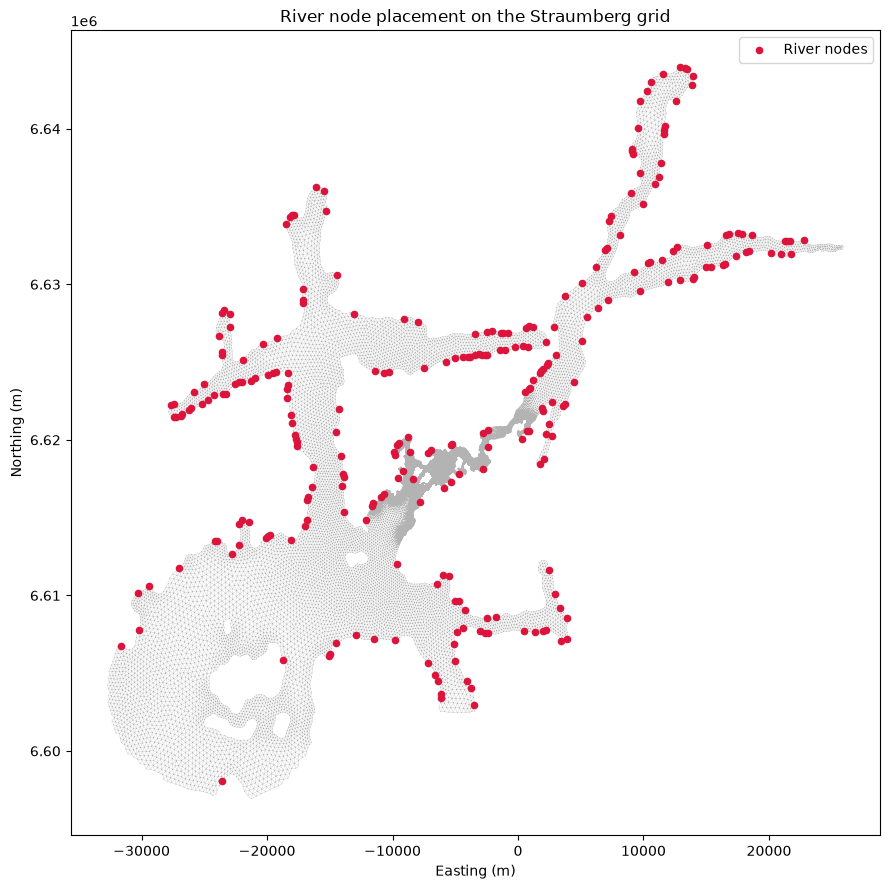

In [18]:
fig, ax = plt.subplots(figsize=(9, 9))
ax.triplot(grid.x_nodes, grid.y_nodes, grid.triangles,
           linewidth=0.2, color='0.7', zorder=1)

river_xs = grid.x_nodes[river_mgr._grid_locations]
river_ys = grid.y_nodes[river_mgr._grid_locations]

ax.scatter(river_xs, river_ys, c='crimson', s=20, zorder=3, label='River nodes')


ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_title('River node placement on the Straumberg grid')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Write Output Files

Write the NetCDF forcing file and the river namelist.  The forcing file
interpolates the processed time series to the requested output grid
(`start_date` → `end_date` at `dt` resolution).

In [19]:
river_mgr.create_forcing_file(
    out_river_nc,
    start_date=start_date,
    end_date=end_date,
    interval=dt,
    ncopts={'zlib': True, 'complevel': 4},
)
print(f'Written: {out_river_nc}')
print(f'File size: {os.path.getsize(out_river_nc) / 1024:.1f} kB')

river_mgr.create_namelist_file(
    out_river_nml,
    forcing_file='river_forcing.nc',  # relative path as FVCOM will see it at run time
    vertical_distribution='uniform',
)
print(f'Written: {out_river_nml}')

print('\nFirst namelist entry:')
with open(out_river_nml) as fh:
    for line in fh:
        print(line, end='')
        if line.strip() == '/':
            break

Written: /home/michael/Code/temp/temp/inputs/river_forcing.nc
File size: 436.2 kB
Written: /home/michael/Code/temp/temp/inputs/river_forcing.nml

First namelist entry:
&NML_RIVER
 RIVER_NAME = 'River_194',
 RIVER_FILE = 'river_forcing.nc',
 RIVER_GRID_LOCATION = 90,
 RIVER_VERTICAL_DISTRIBUTION = '0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412 0.029412'
/


### Example: adding ERSEM biogeochemical variables

If you are running FABM/ERSEM, supply the `ersem` argument to
`add_river_data`.  Missing zooplankton variables (Z4/Z5/Z6) are
auto-populated from WCO L4 initial conditions scaled by 10⁻⁶.

In [9]:
# Example: constant nitrate concentration for all rivers
n3_n = np.full_like(flux, fill_value=15.0)  # mmol N/m³
n1_p = np.full_like(flux, fill_value=1.0)   # mmol P/m³

ersem_vars = {
    'N3_n': n3_n,
    'N1_p': n1_p,
}

river_mgr_ersem = RiverManager(
    grid,
    placement='node',
    distance_threshold=distance_threshold_km,
    flux_threshold=flux_threshold_m3s,
)
river_mgr_ersem.add_river_data(
    lon=lon, lat=lat, names=names, times=times,
    flux=flux, temperature=temp,
    ersem=ersem_vars,
)

print('ERSEM variables that will be written:')
for var in river_mgr_ersem._ersem:
    print(f'  {var}: shape {river_mgr_ersem._ersem[var].shape}')

ERSEM variables that will be written:
  N3_n: shape (6577, 212)
  N1_p: shape (6577, 212)
  Z4_c: shape (6577, 212)
  Z5_c: shape (6577, 212)
  Z5_n: shape (6577, 212)
  Z5_p: shape (6577, 212)
  Z6_c: shape (6577, 212)
  Z6_n: shape (6577, 212)
  Z6_p: shape (6577, 212)


/tmp/ipykernel_32483/3082759142.py:16: UserWarning: 27 river(s) removed: nearest coastline location exceeds 5.0 km threshold.
  river_mgr_ersem.add_river_data(


## 7. Summary

The following files have been written and are ready to be referenced in the
FVCOM run namelist:

| File | Purpose | FVCOM namelist key |
|---|---|---|
| `river_forcing.nc` | Per-river time series of flux, T, S | `RIVER_FILE` (per `&NML_RIVER` block) |
| `river_forcing.nml` | Grid locations and vertical distributions | `RIVER_INFO_FILE` |

Add the following to the FVCOM run namelist (`NML_RIVER_TYPE` section):

```
&NML_RIVER_TYPE
 RIVER_NUMBER     = <n_rivers>,
 RIVER_KIND       = 'variable',
 RIVER_TS_SETTING = 'calculated',
 RIVER_INFLOW_LOCATION = 'node',
 RIVER_INFO_FILE  = 'inputs/river_forcing.nml'
/
```

### Key parameters used

| Parameter | Value | Description |
|---|---|---|
| `placement` | `'node'` | Rivers placed at coastline nodes |
| `distance_threshold` | 5.0 km | Rivers farther than this are dropped |
| `flux_threshold` | 50.0 m³ s⁻¹ | Rivers exceeding this are split |
| `vertical_distribution` | `'uniform'` | Equal flux in each sigma layer |